# RGB -> NIR inference

Loads the trained RGB->NIR U-Net and predicts the NIR band from RGB imagery, so the
predicted NIR can be stacked as a 4th channel (RGB+NIR) for the downstream tree
bounding-box detector.

- The model takes RGB in **[0,1]** (it applies ImageNet normalization internally) and
  outputs NIR in **[0,1]** (sigmoid).
- Trained on 0.6 m native + 1.0/1.5/2.0 m scale augmentation; 0.6 m is the deployment GSD.

Run this from the `NAIP` folder with the `df` conda env as the kernel.

In [9]:
import os
# conda's MKL numpy/pandas load Intel OpenMP (libiomp5md.dll) while pip torch +
# matplotlib load LLVM OpenMP (libomp.dll). Two OpenMP runtimes in one process
# crash the Jupyter kernel with "OMP: Error #15". Setting this BEFORE the imports
# below tolerates the duplicate. Must be the first thing the kernel runs.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys
from pathlib import Path

import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

# This notebook expects to be run from the NAIP project folder (next to train.py).
NAIP_DIR = Path.cwd()
if not (NAIP_DIR / "train.py").exists():
    NAIP_DIR = Path(r"E:\mortalitree_top\mortalitree\synthetic_nir_dev\NAIP")  # fallback
if str(NAIP_DIR) not in sys.path:
    sys.path.insert(0, str(NAIP_DIR))

# Reuse the exact architecture + helpers from train.py so the checkpoint loads cleanly.
from train import build_model, NaipPatchDataset, VAL_RESOLUTIONS_M, ROOT, NDVI_EPS

device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print("device:", device)

device: cuda


In [10]:
CKPT_DIR = NAIP_DIR / "checkpoints"

# Auto-pick the most recently modified run that has a best.pt (override CKPT_PATH if needed).
runs = sorted((d for d in CKPT_DIR.iterdir() if d.is_dir() and (d / "best.pt").exists()),
              key=lambda d: d.stat().st_mtime)
CKPT_PATH = runs[-1] / "best.pt"
print("loading:", CKPT_PATH)

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)  # trusted local checkpoint
model = build_model().to(device).eval()
model.load_state_dict(ckpt["model"])

print("epoch       :", ckpt.get("epoch"))
print("val_metrics :", ckpt.get("val_metrics"))
print("config      :", ckpt.get("config"))

loading: e:\mortalitree_top\mortalitree\synthetic_nir_dev\NAIP\checkpoints\20260530_024257_9kvg65kl\best.pt
epoch       : 18
val_metrics : {'nir_mae': 0.03433813361426189, 'ndvi_mae': 0.03396106218123063}
config      : {'encoder': 'resnet34', 'train_resolutions_m': [0.6, 1.0, 1.5, 2.0], 'ndvi_weight': 0.5, 'batch_size': 48, 'lr': 0.0001}


## Inference

`predict_nir` takes an RGB image (array or file path) of any size and returns the
predicted NIR in [0,1]. It pads to a multiple of 32 (the U-Net's downsampling factor)
and crops back, so it works on 256-px patches and full tiles alike.

In [11]:
@torch.no_grad()
def predict_nir(rgb, model=model, device=device):
    # rgb: (H,W,3) uint8 [0..255] or float [0..1], or an image path. Returns (H,W) float32 NIR in [0,1].
    if isinstance(rgb, (str, Path)):
        rgb = np.array(Image.open(rgb).convert("RGB"))
    arr = np.asarray(rgb)
    arr = arr.astype(np.float32) / 255.0 if arr.dtype == np.uint8 else arr.astype(np.float32)
    H, W = arr.shape[:2]
    t = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)        # (1,3,H,W), [0,1]
    ph, pw = (-H) % 32, (-W) % 32                                  # pad to a multiple of 32
    if ph or pw:
        t = torch.nn.functional.pad(t, (0, pw, 0, ph), mode="reflect")
    t = t.to(device)
    with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == "cuda"):
        out = model(t)
    return out.float()[0, 0, :H, :W].cpu().numpy()                 # crop back to (H,W)

## Visual check on validation patches

RGB | true NIR | predicted NIR | signed error (**blue** = pred low, **red** = pred high) | predicted NDVI.

NIR MAE on these 5 val patches: 0.0277  (error scale +/-0.11)


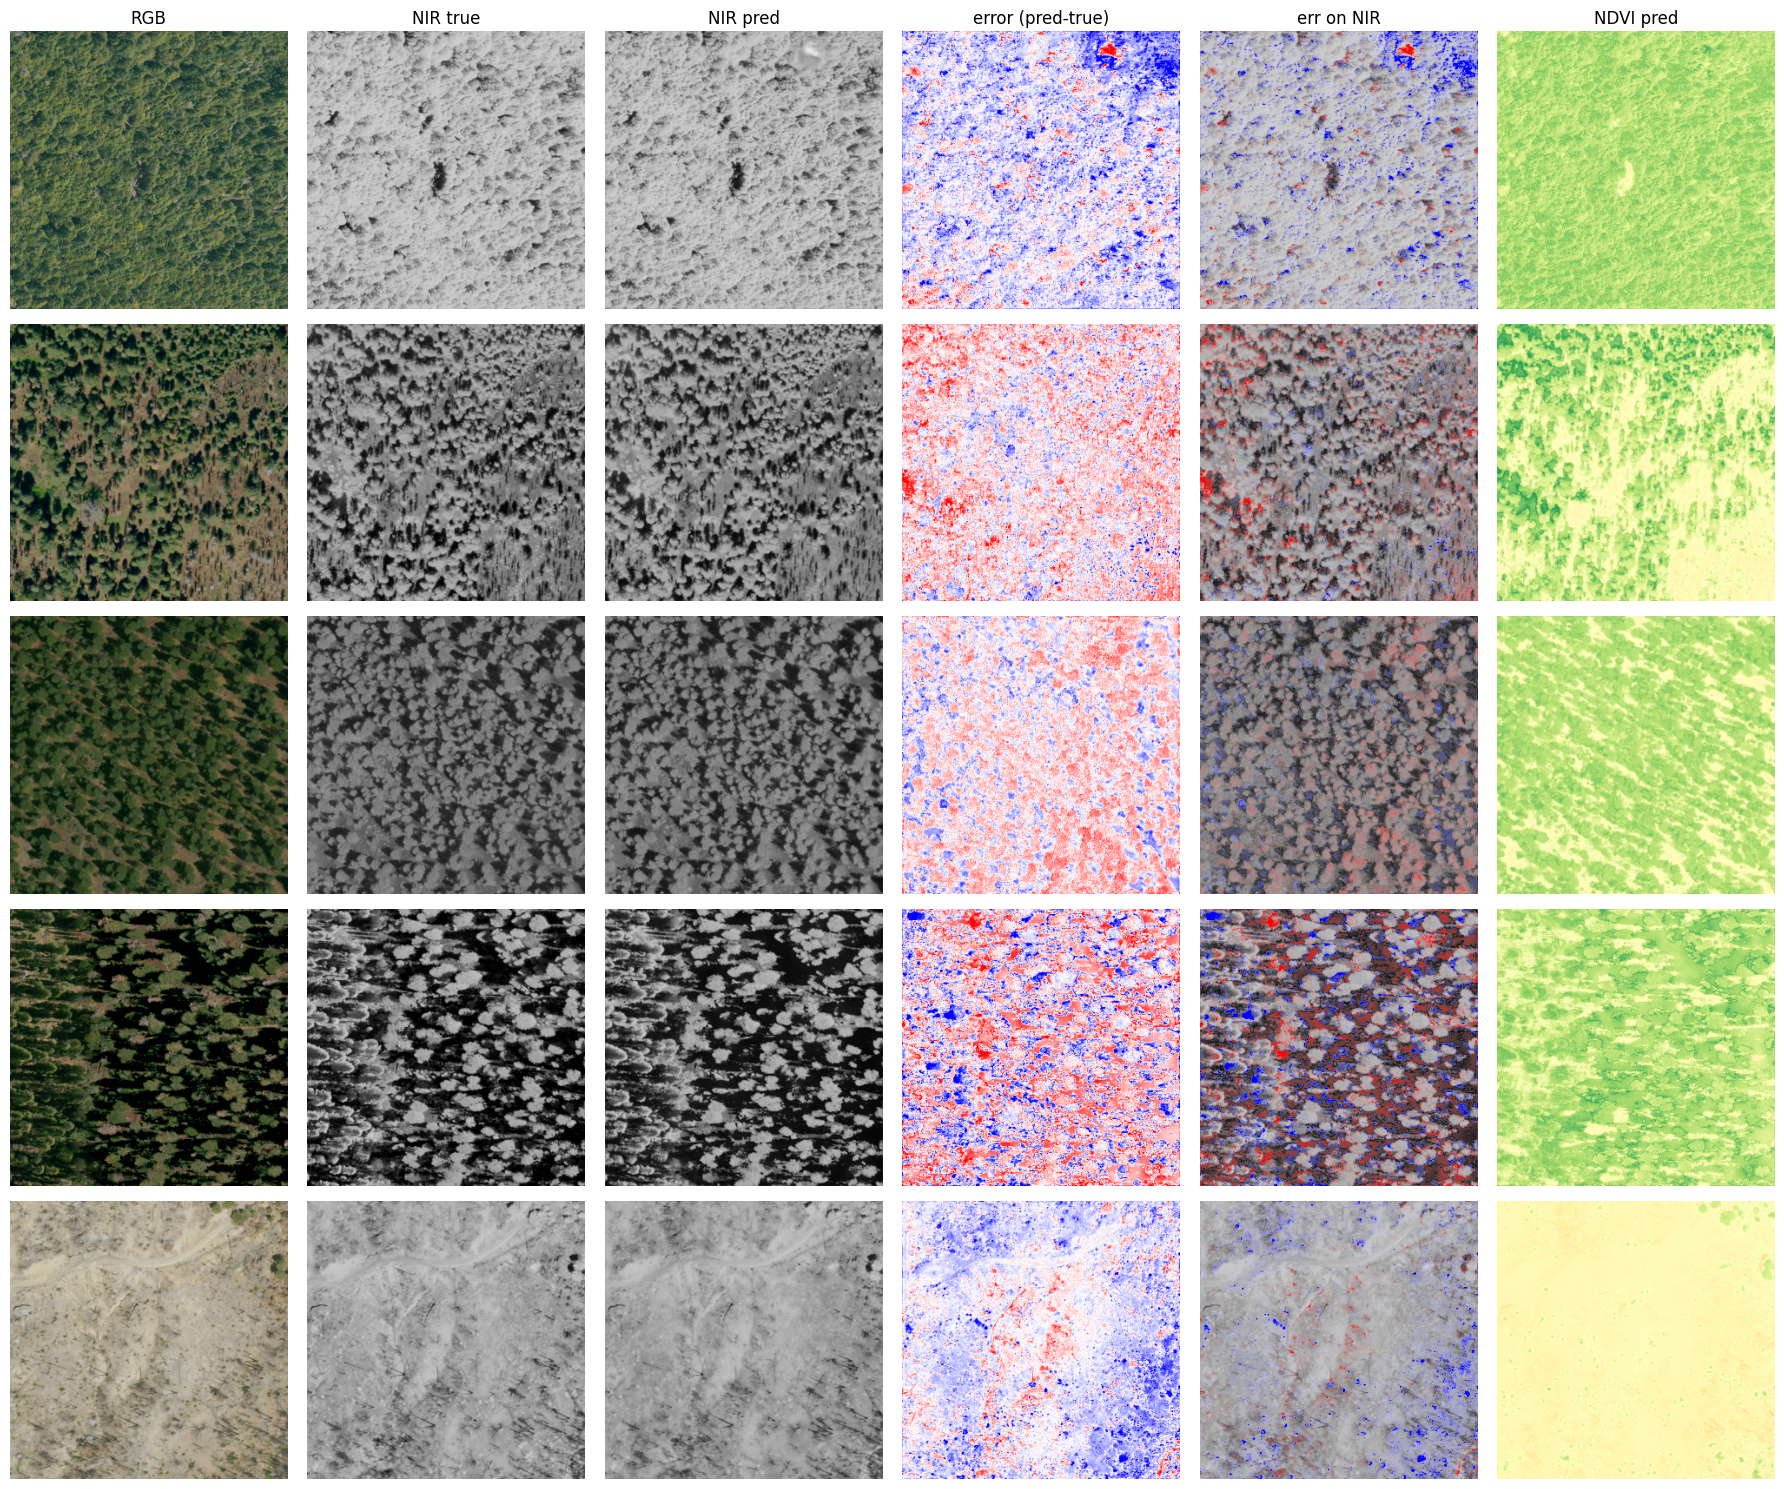

In [13]:
val_ds = NaipPatchDataset("val", VAL_RESOLUTIONS_M, augment=False)
rng = np.random.default_rng(0)
idxs = rng.integers(0, len(val_ds), size=5).tolist()

rgb_b = torch.stack([val_ds[i][0] for i in idxs]).to(device)
nir_true_b = torch.stack([val_ds[i][1] for i in idxs]).to(device)
with torch.no_grad(), torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == "cuda"):
    nir_pred_b = model(rgb_b).float()

err_b = nir_pred_b - nir_true_b                       # signed: + = pred too high, - = pred too low
elim = float(err_b.abs().flatten().quantile(0.99))    # symmetric color limit (99th pct), shared across rows
print(f"NIR MAE on these {len(idxs)} val patches: {err_b.abs().mean().item():.4f}  (error scale +/-{elim:.2f})")

panels = ["RGB", "NIR true", "NIR pred", "error (pred-true)", "err on NIR", "NDVI pred"]
fig, axes = plt.subplots(len(idxs), len(panels), figsize=(3 * len(panels), 3 * len(idxs)))
for r in range(len(idxs)):
    rgb = rgb_b[r].cpu().permute(1, 2, 0).numpy()
    red = rgb[..., 0]
    nt = nir_true_b[r, 0].cpu().numpy()
    npd = nir_pred_b[r, 0].cpu().numpy()
    err = npd - nt
    ndvi_p = (npd - red) / (npd + red + NDVI_EPS)
    imgs = [rgb, nt, npd, err, err, ndvi_p]   # err passed twice; the overlay panel pulls nt from outer scope
    for c, (img, title) in enumerate(zip(imgs, panels)):
        ax = axes[r, c]
        if c == 0:
            ax.imshow(np.clip(img, 0, 1))
        elif title == "NDVI pred":
            ax.imshow(img, cmap="RdYlGn", vmin=-1, vmax=1)
        elif title == "err on NIR":
            ax.imshow(nt, cmap="gray", vmin=0, vmax=1)
            alpha = np.clip(np.abs(img) / elim, 0, 1)   # transparent where pred is right, opaque where it's off
            ax.imshow(img, cmap="bwr", vmin=-elim, vmax=elim, alpha=alpha)
        elif title.startswith("error"):
            # diverging, symmetric about 0: blue = pred < true (under), red = pred > true (over)
            ax.imshow(img, cmap="bwr", vmin=-elim, vmax=elim)
        else:
            ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        if r == 0:
            ax.set_title(title)
        ax.axis("off")
plt.tight_layout()
plt.show()

## Export RGB+NIR (4-channel) for the detector

`to_rgbn` returns an `(H, W, 4)` uint8 array (R, G, B, predicted NIR). Below it saves a
few as `.npy`; swap in your own RGB paths to batch a folder.

In [8]:
def to_rgbn(rgb, model=model, device=device):
    # Returns (H,W,4) uint8: R,G,B + predicted NIR. Feed this to the detector.
    if isinstance(rgb, (str, Path)):
        rgb = np.array(Image.open(rgb).convert("RGB"))
    rgb = np.asarray(rgb)
    if rgb.dtype != np.uint8:
        rgb = (np.clip(rgb, 0, 1) * 255).round().astype(np.uint8)
    nir = predict_nir(rgb, model, device)
    nir_u8 = (np.clip(nir, 0, 1) * 255).round().astype(np.uint8)
    return np.dstack([rgb, nir_u8])

# Demo: build RGBN for a few validation patches and save as .npy (H,W,4 uint8).
out_dir = NAIP_DIR / "rgbn_demo"
out_dir.mkdir(exist_ok=True)
for i in idxs[:3]:
    rgb_path = ROOT / val_ds.rgb_paths[i]
    rgbn = to_rgbn(rgb_path)
    np.save(out_dir / f"{rgb_path.stem}_rgbn.npy", rgbn)
print("wrote RGBN arrays to", out_dir, "| example shape/dtype:", rgbn.shape, rgbn.dtype)

wrote RGBN arrays to /Users/so/Desktop/trees/synthetic_nir_dev/NAIP/rgbn_demo | example shape/dtype: (256, 256, 4) uint8


## Notes

- **Single image:** `nir = predict_nir("path/to/rgb.png")` -> `(H,W)` float in [0,1].
- **4-channel for the detector:** `rgbn = to_rgbn("path/to/rgb.png")` -> `(H,W,4)` uint8.
- **Whole NAIP tiles:** `predict_nir` handles any size, but a full tile may exceed 8 GB
  VRAM. If you hit OOM, run it in windows (e.g. 1024 px with a small overlap) and stitch;
  the network is fully convolutional so seams are minimal.
- **NDVI** from a prediction: `(nir - red) / (nir + red + NDVI_EPS)`, `red` = input red in [0,1].
- The model expects RGB in **[0,1]**; `predict_nir`/`to_rgbn` handle the scaling for you.